# Recurrence Classifier with Validation

Not using clinical data since validation dataset doesn't have those features

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.pipeline import Pipeline

from recurrence_data import *

## Load Expression-Only Data

In [2]:
recurrence_data = load_recurrence_data()
data = recurrence_data["data"]

expression_features = recurrence_data["expression_features"]

X = data[expression_features].copy()
y = data[TARGET_COLUMN].astype(int)
groups = data[GROUP_COLUMN].astype(str)

val_data = load_validation_rec_data(
    train_expression_features=expression_features
)

X_val = val_data["X"]
y_val = val_data["y"]
val_meta = val_data["metadata"]

print("PNAS X:", X.shape)
print("PNAS labels:")
print(y.value_counts().rename(index={0: "Nonrecurrent", 1: "Recurrent"}))
print("PNAS donors:", groups.nunique())
print("Validation X:", X_val.shape)
print("Validation labels:")
print(y_val.value_counts().rename(index={0: "Nonrecurrent", 1: "Recurrent"}))
print("Validation columns match PNAS expression columns:", list(X_val.columns) == list(X.columns))
print("Overlapping expression features:", len(val_data["common_expression_features"]))
print("Missing expression features:", len(val_data["missing_expression_features"]))

PNAS X: (96, 42551)
PNAS labels:
recurrence_status
Nonrecurrent    68
Recurrent       28
Name: count, dtype: int64
PNAS donors: 44
Validation X: (83, 42551)
Validation labels:
recurrence_status
Nonrecurrent    75
Recurrent        8
Name: count, dtype: int64
Validation columns match PNAS expression columns: True
Overlapping expression features: 42551
Missing expression features: 0


## Train/Test Split and Evaluation Helper

In [3]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X,
    y,
    groups,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

trained_models = {}
pnas_results = []
validation_results = []


def evaluate_model(model, X_eval, y_eval, title):
    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_eval)
    else:
        y_score = None

    metrics = {
        "model": title,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_score) if y_score is not None else np.nan,
    }

    conf_matrix = confusion_matrix(y_eval, y_pred)
    print(title)
    for metric_name in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        print(f"{metric_name}: {metrics[metric_name]:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

    labels = np.array([["TN", "FP"], ["FN", "TP"]])
    annot_matrix = np.empty(conf_matrix.shape, dtype=object)
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            annot_matrix[i, j] = f"{conf_matrix[i, j]} ({labels[i, j]})"

    _, counts = np.unique(y_eval, return_counts=True)
    max_counts = max(counts)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=annot_matrix,
        cmap="Blues",
        fmt="",
        annot_kws={"size": 15},
        vmin=0,
        vmax=max_counts,
    )
    plt.title(f"{title} Confusion Matrix", fontsize=18)
    plt.ylabel("Actual", fontsize=18)
    plt.xlabel("Predicted", fontsize=18)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.show()

    return metrics


print("y value counts:")
print(y.value_counts())
print("y_train value counts:")
print(y_train.value_counts())
print("y_test value counts:")
print(y_test.value_counts())
print("groups_train value counts:")
print(groups_train.value_counts())
print("groups_test value counts:")
print(groups_test.value_counts())

y value counts:
recurrence_status
0    68
1    28
Name: count, dtype: int64
y_train value counts:
recurrence_status
0    54
1    22
Name: count, dtype: int64
y_test value counts:
recurrence_status
0    14
1     6
Name: count, dtype: int64
groups_train value counts:
poiseid
2011    4
6027    4
6039    3
2018    3
6019    2
2048    2
2097    2
2005    2
6056    2
2002    2
2003    2
6021    2
2041    2
2060    2
6022    2
6017    2
6057    2
2065    2
6044    2
6060    2
2039    2
6035    2
6040    2
6062    2
2075    2
6045    2
6049    2
2028    2
2010    1
6043    1
2023    1
2014    1
2056    1
2006    1
6034    1
2038    1
6028    1
2031    1
2024    1
2091    1
6038    1
6023    1
Name: count, dtype: int64
groups_test value counts:
poiseid
2074    2
6025    2
2010    1
2056    1
6038    1
2024    1
2031    1
6043    1
6034    1
6028    1
2023    1
2038    1
2006    1
2091    1
2014    1
2018    1
6045    1
6023    1
Name: count, dtype: int64


# Whole Dataset

## Logistic Regression

LR CV ROC-AUC mean: 0.6169
LR CV ROC-AUC std: 0.1485
Classes: [0 1]
Logistic Regression - PNAS Test
accuracy: 0.7000
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.3810
Confusion Matrix:
[[14  0]
 [ 6  0]]


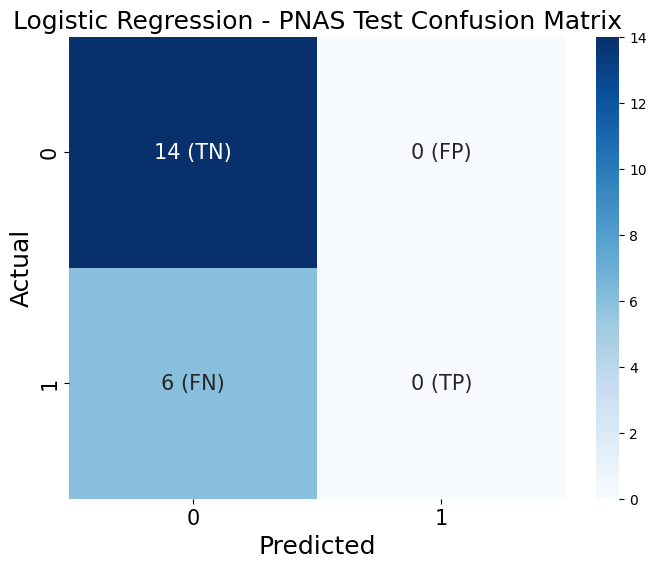

In [4]:
LR_Model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")),
])

LR_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
LR_cross_scores = cross_val_score(
    LR_Model,
    X_train,
    y_train,
    cv=LR_cv,
    groups=groups_train,
    scoring="roc_auc",
)
print(f"LR CV ROC-AUC mean: {LR_cross_scores.mean():.4f}")
print(f"LR CV ROC-AUC std: {LR_cross_scores.std():.4f}")

LR_Model.fit(X_train, y_train)
trained_models["Logistic Regression"] = LR_Model
print("Classes:", LR_Model.named_steps["classifier"].classes_)

pnas_results.append(evaluate_model(LR_Model, X_test, y_test, "Logistic Regression - PNAS Test"))

## Random Forest

RF CV ROC-AUC mean: 0.5704
RF CV ROC-AUC std: 0.1367
Random Forest - PNAS Test
accuracy: 0.7000
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.6905
Confusion Matrix:
[[14  0]
 [ 6  0]]


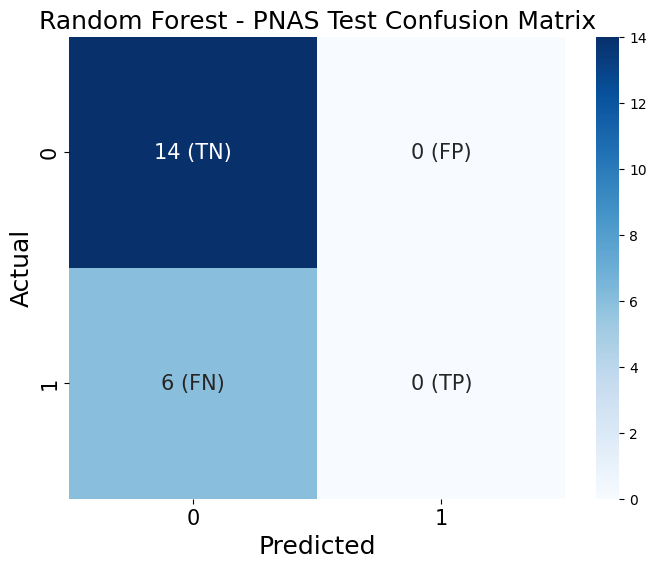

In [5]:
RF_Model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

RF_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
RF_cross_scores = cross_val_score(
    RF_Model,
    X_train,
    y_train,
    cv=RF_cv,
    groups=groups_train,
    scoring="roc_auc",
)
print(f"RF CV ROC-AUC mean: {RF_cross_scores.mean():.4f}")
print(f"RF CV ROC-AUC std: {RF_cross_scores.std():.4f}")

RF_Model.fit(X_train, y_train)
trained_models["Random Forest"] = RF_Model

pnas_results.append(evaluate_model(RF_Model, X_test, y_test, "Random Forest - PNAS Test"))

## Naive Bayes

NB CV ROC-AUC mean: 0.5000
NB CV ROC-AUC std: 0.0000
Naive Bayes - PNAS Test
accuracy: 0.7000
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.5000
Confusion Matrix:
[[14  0]
 [ 6  0]]


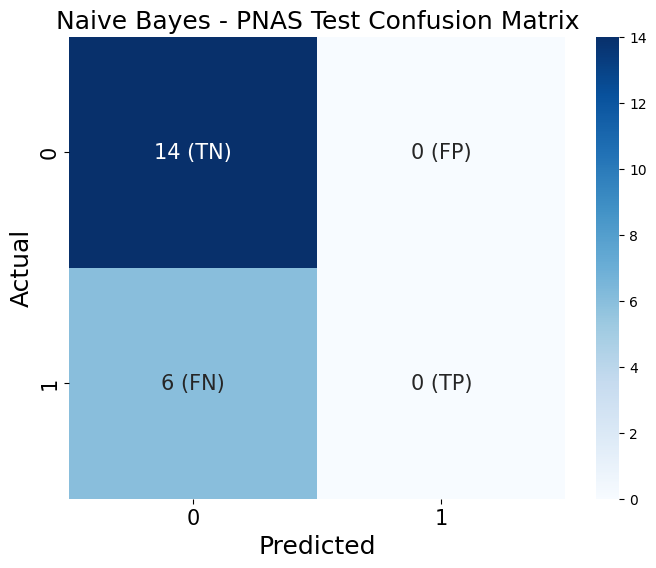

In [6]:
NB_Model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("classifier", GaussianNB()),
])

NB_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
NB_cross_scores = cross_val_score(
    NB_Model,
    X_train,
    y_train,
    cv=NB_cv,
    groups=groups_train,
    scoring="roc_auc",
)
print(f"NB CV ROC-AUC mean: {NB_cross_scores.mean():.4f}")
print(f"NB CV ROC-AUC std: {NB_cross_scores.std():.4f}")

NB_Model.fit(X_train, y_train)
trained_models["Naive Bayes"] = NB_Model

pnas_results.append(evaluate_model(NB_Model, X_test, y_test, "Naive Bayes - PNAS Test"))

## Support Vector Machine

SVM CV ROC-AUC mean: 0.5546
SVM CV ROC-AUC std: 0.1295
Support Vector Machine - PNAS Test
accuracy: 0.7000
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.4405
Confusion Matrix:
[[14  0]
 [ 6  0]]


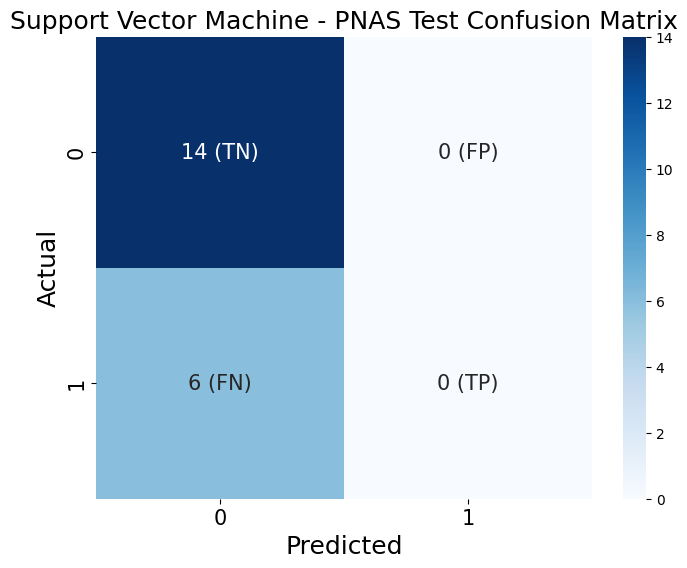

In [7]:
SVM_Model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("classifier", SVC(probability=True, class_weight="balanced", random_state=42)),
])

SVM_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
SVM_cross_scores = cross_val_score(
    SVM_Model,
    X_train,
    y_train,
    cv=SVM_cv,
    groups=groups_train,
    scoring="roc_auc",
)
print(f"SVM CV ROC-AUC mean: {SVM_cross_scores.mean():.4f}")
print(f"SVM CV ROC-AUC std: {SVM_cross_scores.std():.4f}")

SVM_Model.fit(X_train, y_train)
trained_models["Support Vector Machine"] = SVM_Model

pnas_results.append(evaluate_model(SVM_Model, X_test, y_test, "Support Vector Machine - PNAS Test"))

## PNAS Test Set Summary

In [8]:
pnas_results_df = pd.DataFrame(pnas_results).set_index("model")
pnas_results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression - PNAS Test,0.7,0.0,0.0,0.0,0.380952
Random Forest - PNAS Test,0.7,0.0,0.0,0.0,0.690476
Naive Bayes - PNAS Test,0.7,0.0,0.0,0.0,0.500000
Support Vector Machine - PNAS Test,0.7,0.0,0.0,0.0,0.440476


# Validation Dataset Evaluation

Validation X: (83, 42551)
Validation labels:
recurrence_status
Nonrecurrent    75
Recurrent        8
Name: count, dtype: int64
Overlapping expression features: 42551
Missing expression features: 0
Validation columns match training columns: True
Logistic Regression - Validation
accuracy: 0.7952
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.4333
Confusion Matrix:
[[66  9]
 [ 8  0]]


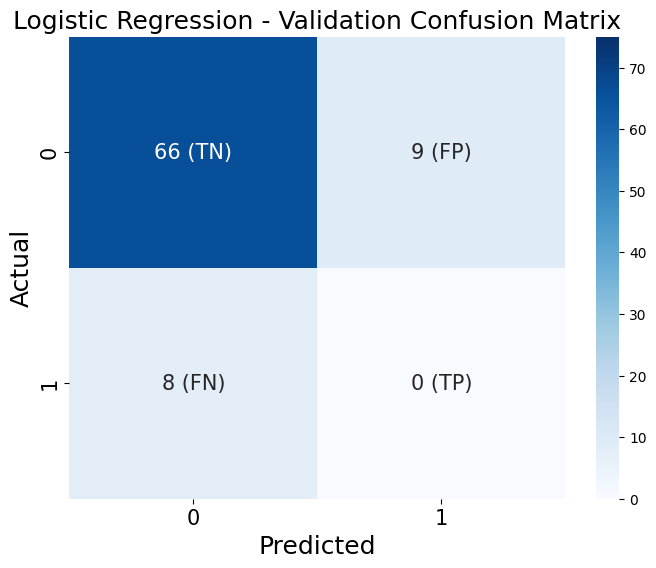

Random Forest - Validation
accuracy: 0.9036
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.5467
Confusion Matrix:
[[75  0]
 [ 8  0]]


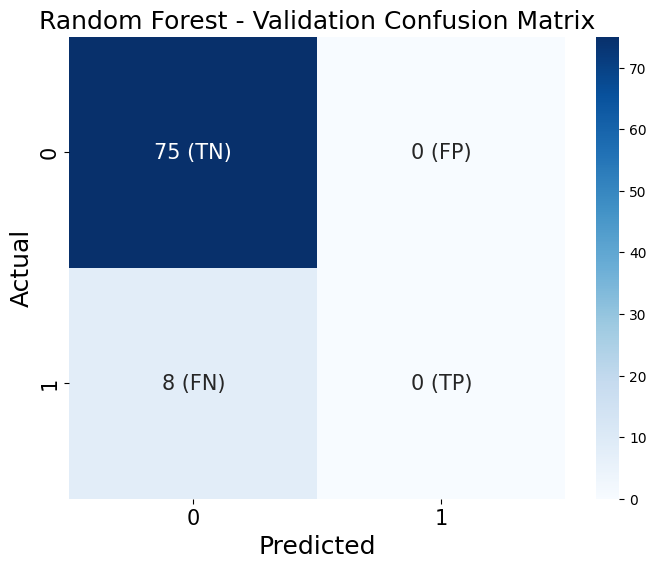

Naive Bayes - Validation
accuracy: 0.8916
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.4933
Confusion Matrix:
[[74  1]
 [ 8  0]]


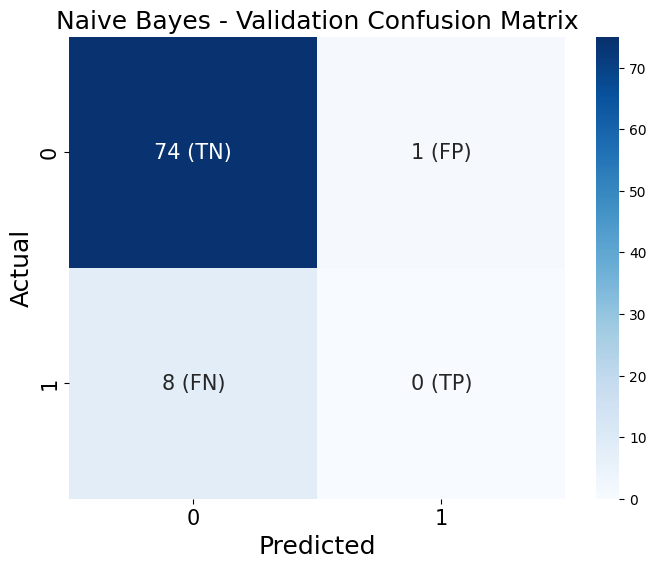

Support Vector Machine - Validation
accuracy: 0.9036
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.5433
Confusion Matrix:
[[75  0]
 [ 8  0]]


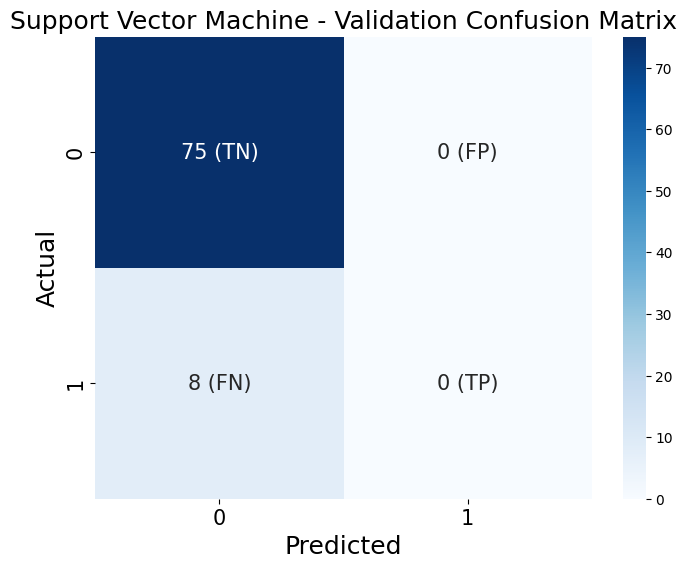

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression - Validation,0.795181,0.0,0.0,0.0,0.433333
Random Forest - Validation,0.903614,0.0,0.0,0.0,0.546667
Naive Bayes - Validation,0.891566,0.0,0.0,0.0,0.493333
Support Vector Machine - Validation,0.903614,0.0,0.0,0.0,0.543333


In [9]:
print("Validation X:", X_val.shape)
print("Validation labels:")
print(y_val.value_counts().rename(index={0: "Nonrecurrent", 1: "Recurrent"}))
print("Overlapping expression features:", len(val_data["common_expression_features"]))
print("Missing expression features:", len(val_data["missing_expression_features"]))
print("Validation columns match training columns:", list(X_val.columns) == list(X.columns))

validation_results = []
for model_name, model in trained_models.items():
    validation_results.append(
        evaluate_model(model, X_val, y_val, f"{model_name} - Validation")
    )

validation_results_df = pd.DataFrame(validation_results).set_index("model")
validation_results_df